In [78]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from gena_expression.conditions import Condition, DescriptionLookup
from gena_expression.genome import Genome
from gena_expression.models import SequenceModel
from gena_expression.sequences import AnnotatedSequence, Feature

In [2]:
# Paths and constants used by later cells

from pathlib import Path

GENA_LM_ROOT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "GENA_LM" # CHANGE THIS LINE

EXPRESSION_TASK_DIR = GENA_LM_ROOT / "downstream_tasks" / "expression_prediction"

MODEL_CLS = EXPRESSION_TASK_DIR / "expression_model_final.py"
MODEL_CLS = f"{MODEL_CLS}::ExpressionCounts"

MODEL_CHECKPOINT = Path("/workspace-SR003.nfs2/estsoi/CAGI5_benchmark") / "models" / "expression_model" / "pytorch_model.bin" # CHANGE THIS LINE
MODEL_CONFIG = EXPRESSION_TASK_DIR / "inference_example_config.yaml" # CHANGE THIS LINE
DNA_TOKENIZER = GENA_LM_ROOT / "data" / "tokenizers" / "t2t_1000h_multi_32k"
DESCRIPTION_TOKENIZER = "Qwen/Qwen3-Embedding-0.6B"

DATA_DIR = Path("../data").resolve()
DESCRIPTION_DIR = DATA_DIR / "real_descriptions"

GENOME_FASTA = Path("/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa") # CHANGE THIS LINE
GENOME_ANNOTATION = Path(
    "/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/"
    "downstream_tasks/expression_prediction/datasets/data/genomes/hg38/"
    "gencode.v29.primary_assembly.annotation_UCSC_names.gtf"
) # CHANGE THIS LINE

DEVICE = "cuda:5"
os.environ["GENALM_HOME"] = Path('../../../../..').resolve().__str__() # CHANGE THIS LINE

## Load the expression prediction model

Here we load the GENA-LM expression model through the API wrapper. The wrapper handles the model class import, checkpoint loading, Hydra config, DNA tokenizer, description tokenizer, and device placement.

The DNA-side parameters define how genomic sequence is tokenized around a biological center:

- `dna_max_seq_len=1024`: maximum number of DNA tokens including special tokens.
- `num_before=511`: number of DNA tokens kept upstream of the center.
- `token_len_for_fetch=9`: approximate nucleotide span used when fetching sequence before tokenization.
- `desc_max_seq_len=510`: maximum length for metadata / experiment-description tokens.

This setup uses centered tokenization, so it is intended for coordinate-aware API inference rather than exact reproduction of the original notebook's plain full-sequence tokenization.

In [3]:
model = SequenceModel.load(
    model_cls=MODEL_CLS,
    checkpoint=MODEL_CHECKPOINT,
    config=MODEL_CONFIG,
    dna_tokenizer=DNA_TOKENIZER,
    description_tokenizer=DESCRIPTION_TOKENIZER,
    dna_max_seq_len=1024,
    num_before=511,
    desc_max_seq_len=510,
    token_len_for_fetch=9,
    device=DEVICE,
)

/home/jovyan/miniconda3/envs/api/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspace-SR003.nfs2/estsoi/API/GENA_LM/downstream_tasks/expression_prediction/api/src/gena_expression/models.py:183: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize_config_dir(str(config_path.parents[0])):


Using ModernGENA from AIRI-Institute/moderngena-large


Flash Attention 2 only supports torch.float16 and torch.bfloat16 dtypes, but the current dype in ModernBertModel is torch.float32. You should run training or inference using Automatic Mixed-Precision via the `with torch.autocast(device_type='torch_device'):` decorator, or load the model with the `torch_dtype` argument. Example: `model = AutoModel.from_pretrained("openai/whisper-tiny", attn_implementation="flash_attention_2", torch_dtype=torch.float16)`


missing: 0 []
unexpected: 3 ['decoder.bias', 'head.dense.weight', 'head.norm.weight']
mismatched: []
bert dropouts: {'attention_dropout': 0.1, 'embedding_dropout': 0.1, 'mlp_dropout': 0.1}
qwen dropouts: {'attention_dropout': 0.1}
[desc_model] unfrozen transformer blocks: [24, 25, 26, 27] (total blocks=28)
[desc_model] backbone.norm trainable: True (trainable params=1,024)
[desc_model] trainable params: 62,924,800 / 595,776,512
[desc_model] trainable tensors: 45
  - layers.24.self_attn.q_proj.weight
  - layers.24.self_attn.k_proj.weight
  - layers.24.self_attn.v_proj.weight
  - layers.24.self_attn.o_proj.weight
  - layers.24.self_attn.q_norm.weight
  - layers.24.self_attn.k_norm.weight
  - layers.24.mlp.gate_proj.weight
  - layers.24.mlp.up_proj.weight
  - layers.24.mlp.down_proj.weight
  - layers.24.input_layernorm.weight
  - layers.24.post_attention_layernorm.weight
  - layers.25.self_attn.q_proj.weight
  - layers.25.self_attn.k_proj.weight
  - layers.25.self_attn.v_proj.weight
  - l

## Select experiment descriptions

`DescriptionLookup` reads metadata JSON files and deterministically selects one metadata record per requested cell type.

Here we explicitly pin each cell type to a known metadata file ID:

- `K562` -> `ENCFF578UUD`
- `HepG2` -> `ENCFF588KDY`
- `H1` -> `ENCFF081FQX`

The selected metadata records are later converted into natural-language descriptions and passed through the text tokenizer.

In [4]:
lookup = DescriptionLookup(
    json_dir=DESCRIPTION_DIR,
    keys=["K562", "HepG2", "H1"],
    K562={"id": "ENCFF578UUD"},
    HepG2={"id": "ENCFF588KDY"},
    H1={"id": "ENCFF081FQX"},
)

## Load the genome and annotations

`Genome` provides FASTA-backed sequence retrieval. We also pass a GTF annotation file, so fetched sequences can carry genomic feature annotations such as genes, transcripts, and exons.

Coordinates used by the API are 0-based by default. The annotation loader converts GTF's 1-based inclusive coordinates into internal 0-based half-open intervals.

In [8]:
genome = Genome(
    fasta_path=GENOME_FASTA,
    annotation=GENOME_ANNOTATION,
)

tss_coords = {
    "Sox2": ('chr3', 181711924, '+'),
    "Nanog": ('chr12', 7789414, '+'),
    "HBB": ('chr11', 5227072, '-'),
    'ALB': ('chr4', 73404239, '+')
	   }

(<Figure size 700x1000 with 4 Axes>,
 <Axes: title={'center': 'Annotated sequence'}, xlabel='Sequence coordinate'>)

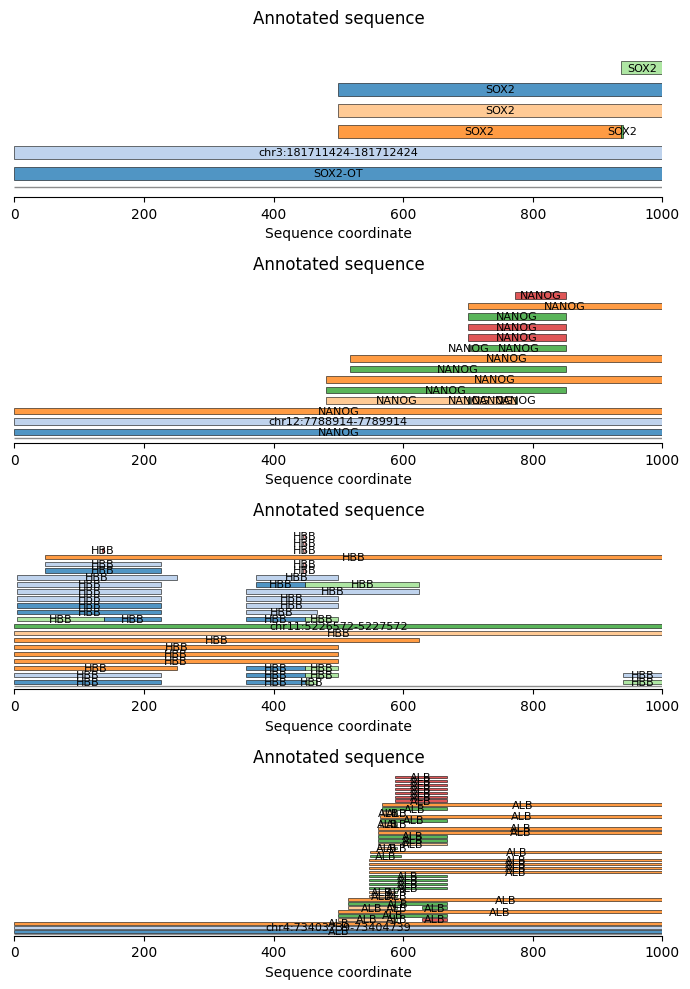

In [6]:
#make sure that TSS is always in the middle
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(7,10))
#plot sox2
Sox2_chrom, Sox2_interval_start, Sox2_interval_end = tss_coords['Sox2'][0], tss_coords['Sox2'][1]-500, tss_coords['Sox2'][1]+500
genome.sequence(Sox2_chrom, Sox2_interval_start, Sox2_interval_end).plot_annotations(ax=axs[0], show_legend=False, hide_types=('source', 'transcript'))
#plot nanog
Nanog_chrom, Nanog_interval_start, Nanog_interval_end = tss_coords['Nanog'][0], tss_coords['Nanog'][1]-500, tss_coords['Nanog'][1]+500
genome.sequence(Nanog_chrom, Nanog_interval_start, Nanog_interval_end).plot_annotations(ax=axs[1], show_legend=False)
#plot HBB
HBB_chrom, HBB_interval_start, HBB_interval_end = tss_coords['HBB'][0], tss_coords['HBB'][1]-500, tss_coords['HBB'][1]+500
genome.sequence(HBB_chrom, HBB_interval_start, HBB_interval_end).plot_annotations(ax=axs[2], show_legend=False)
#plot ALB
ALB_chrom, ALB_interval_start, ALB_interval_end = tss_coords['ALB'][0], tss_coords['ALB'][1]-500, tss_coords['ALB'][1]+500
genome.sequence(ALB_chrom, ALB_interval_start, ALB_interval_end).plot_annotations(ax=axs[3], show_legend=False)

For every `(cell type, gene)` pair, we fetch a 20 kb sequence centered on the gene's TSS, tokenize it around the TSS, and predict expression under the selected cell-type condition.

Important arguments:

- `genome`: FASTA-backed genome object.
- `chrom`, `tss`, `strand`: genomic TSS definition.
- `condition`: metadata record selected by `DescriptionLookup`.
- `coordinate_system="0-based"`: tells the API that TSS coordinates are already 0-based.
- `context_bp=20000`: fetches a 20 kb window around the TSS.

The output is a predicted expression value, interpreted as `log(TPM + 1)`.

In [9]:
results = []
for cell_type in lookup.keys():
    for gene in tss_coords.keys():
        expression = model.predict_tss(genome=genome, 
                                        tss=tss_coords[gene][1], 
                                        chrom=tss_coords[gene][0], 
                                        strand=tss_coords[gene][2],
                                        condition=lookup[cell_type],
                                        coordinate_system='0-based',
                                        context_bp=20000).expression
        results.append(
            (cell_type, gene, expression)
        )

The bar plot compares predicted expression across genes and cell types.

Expected qualitative behavior:

- `ALB` should be high in the liver-derived `HepG2` condition.
- `HBB` should be higher in the blood-related `K562` condition.
- pluripotency-associated genes such as `Sox2` and `Nanog` should be more active in the embryonic stem cell condition `H1`.

In [10]:
def plot_results(results:list):
    df = pd.DataFrame(results)
    df.columns = ['Cell Type', 'Gene', 'Expression']
    print (df)
    plt.figure(figsize=(2.5, 5))
    sns.barplot(x='Gene', y='Expression', hue='Cell Type', data=df, palette='gray')
    plt.xlabel('Gene', fontsize=12)
    plt.ylabel('Expression (log(TPM+1))', fontsize=12)
    plt.grid(True, axis='y')
    plt.show()

   Cell Type   Gene  Expression
0       K562   Sox2    0.064941
1       K562  Nanog    0.128906
2       K562    HBB    1.000000
3       K562    ALB    0.163086
4      HepG2   Sox2    0.253906
5      HepG2  Nanog    0.059814
6      HepG2    HBB    0.086914
7      HepG2    ALB    9.312500
8         H1   Sox2    2.640625
9         H1  Nanog    1.359375
10        H1    HBB    0.027954
11        H1    ALB    0.136719


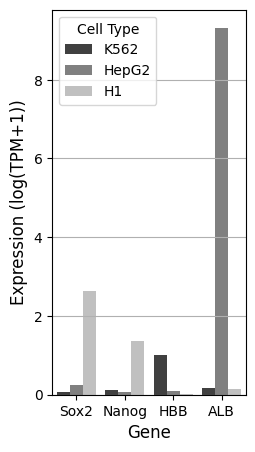

In [11]:
plot_results(results)

## Batch Inference

When we need predictions for many sequence-condition pairs, it is faster to call the batch API once instead of looping over `predict_sequence()` or `predict_tss()`.

Batch prediction helps because the API can:
- tokenize many sequences in parallel with `preprocessing_workers`;
- reuse repeated DNA sequences or repeated condition descriptions with `grouping`;
- send larger tensors through the model, reducing Python overhead;
- return a list of `ExpressionPrediction` objects with the same fields as single-row prediction.

The main batch functions are:

`model.predict_multiple_sequences(...)`  
Use this when sequences are already available as strings or `AnnotatedSequence` objects.

Important arguments:
- `sequences`: one sequence, or a list of sequences.
- `conditions`: row-wise list of `Condition` objects, strings, or metadata dictionaries.
- `condition`: one condition broadcast to all sequences.
- `center`: feature name or coordinate used for centered DNA tokenization, for example `"tss"`.
- `strand`: strand used during tokenization.
- `grouping`: `"no_grouping"`, `"sequence"`, `"condition"`, or `"auto"`.
- `preprocessing_workers`: number of workers for CPU-side tokenization.
- `max_records_per_forward`: optional chunk size for large batches.
- `return_tokens`: whether to keep token-level metadata in each prediction.

`model.predict_multiple_tss(...)`  
Use this when you have TSS records and want the API to fetch genome context automatically.

Important arguments:
- `records`: list of records containing at least `chrom`, `tss`, and optionally `strand` and `name`.
- `conditions` / `condition`: same meaning as above.
- `genome`: `Genome` object used to fetch sequence context.
- `context_bp`: number of base pairs around the TSS.
- `coordinate_system`: `"0-based"` or `"1-based"`.
- `center_feature_name`: feature name added at the TSS, usually `"tss"`.
- `grouping`, `preprocessing_workers`, `max_records_per_forward`: same batching controls as above.

### Batch Prediction From Genome-Built Sequences

Here we first create `AnnotatedSequence` objects with `genome.sequence_around(...)`.  
This is useful when we want explicit sequence objects with names, genomic features, and a marked TSS position before running the model.

Each row in the batch is one `(sequence, condition)` pair. Since the same TSS sequence is evaluated across multiple cell types, `grouping="sequence"` lets the API reuse repeated DNA representations instead of recomputing them for every condition.

In [85]:
tss_records = [
    {
        "name": gene,
        "chrom": chrom,
        "tss": tss,
        "strand": strand,
    }
    for gene, (chrom, tss, strand) in tss_coords.items()
]

sequences = []
conditions = []
for cell_type in lookup.keys():
    for tss_record in tss_records:
        sequence = genome.sequence_around(
                chrom = tss_record["chrom"],
                center = tss_record["tss"],
                size = 20_000,
                strand=tss_record["strand"],
                include_features=True,
                center_feature_name="tss",
                name=tss_record["name"])
        sequences.append(sequence)
        conditions.append(
            Condition(name=cell_type, description=lookup[cell_type])
            )

predictions = model.predict_multiple_sequences(
    sequences,
    conditions=conditions,
    center="tss",
    return_tokens=True,
    preprocessing_workers=10,
    grouping='sequence'
)

results = []
for prediction in predictions:
    results.append(
        (prediction.condition.name, prediction.sequence.name, prediction.expression)
    )

   Cell Type   Gene  Expression
0       K562   Sox2    0.066406
1       K562  Nanog    0.131836
2       K562    HBB    1.023438
3       K562    ALB    0.159180
4      HepG2   Sox2    0.251953
5      HepG2  Nanog    0.052490
6      HepG2    HBB    0.072266
7      HepG2    ALB    9.312500
8         H1   Sox2    2.625000
9         H1  Nanog    1.328125
10        H1    HBB    0.029175
11        H1    ALB    0.127930


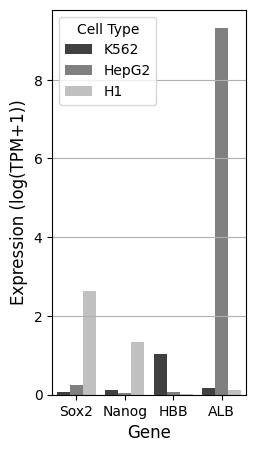

In [86]:
plot_results(results)

### Batch Prediction Directly From TSS Coordinates

The loop below calls `predict_tss(...)` one row at a time. The batch equivalent is `predict_multiple_tss(...)`: we prepare all TSS records and matching conditions first, then call the model once.

This avoids repeated Python/model-call overhead and lets the API parallelize genome fetching and tokenization with `preprocessing_workers`.

### Note on `preprocessing_workers`

For TSS-based prediction, `preprocessing_workers` controls how many separate worker processes are used for genome fetching and tokenization.

Using more workers is not always faster. When `preprocessing_workers > 0`, each worker process initializes its own genome object and tokenizer state. This setup can be expensive, especially for small or medium-sized batches.

When `preprocessing_workers=0`, the function uses the already existing `genome` object in the main process and skips creating extra genome objects. Because of that, `preprocessing_workers=0` can be faster in many notebook-scale examples.

Use `preprocessing_workers > 0` mainly for very large datasets, where the cost of creating worker processes is outweighed by parallel genome fetching and tokenization. For smaller examples, start with:

```python
preprocessing_workers=0

In [89]:
records = []
conditions = []

for cell_type in lookup.keys():
    for gene, (chrom, tss, strand) in tss_coords.items():
        records.append(
            {
                "chrom": chrom,
                "tss": tss,
                "strand": strand,
                "name": gene,
            }
        )
        conditions.append(
            Condition(name=cell_type, description=lookup[cell_type])
        )

predictions = model.predict_multiple_tss(
    records=records,
    conditions=conditions,
    genome=genome,
    coordinate_system="0-based",
    context_bp=20_000,
    center_feature_name="tss",
    preprocessing_workers=0,
    grouping="no_grouping",
    return_sequence=True,
)

results = []
for prediction in predictions:
    results.append(
        (prediction.condition.name, prediction.sequence.name, prediction.expression)
    )

   Cell Type   Gene  Expression
0       K562   Sox2    0.061768
1       K562  Nanog    0.133789
2       K562    HBB    1.015625
3       K562    ALB    0.157227
4      HepG2   Sox2    0.253906
5      HepG2  Nanog    0.061768
6      HepG2    HBB    0.078125
7      HepG2    ALB    9.375000
8         H1   Sox2    2.625000
9         H1  Nanog    1.328125
10        H1    HBB    0.029175
11        H1    ALB    0.127930


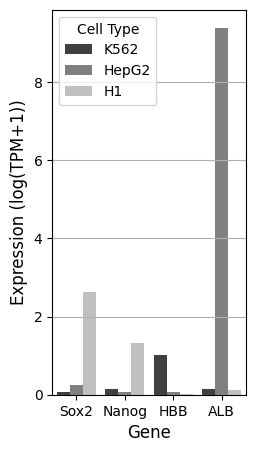

In [90]:
plot_results(results=results)

### Batch Prediction From Bare Sequences

This example starts from plain sequence strings rather than genomic coordinates.

The `@` marker is used only as a notebook convenience to indicate the TSS position. Before prediction, we remove it from the DNA sequence and store its position as a `Feature(name="tss", ...)` inside an `AnnotatedSequence`.

Here `grouping="no_grouping"` runs each `(sequence, condition)` row directly. This is the most explicit mode and is a good default when comparing against another inference path or when every row should be treated independently.

In [53]:
gene2seq = {'HBB': 'CTTGAATACCTAAACAGAATCTGTTGTTTCCTTGTGTTTGAAAGTGCTTTCACAGTAACTCTGTCTGTACTGCCAGAATATACTGACAATGTGTTATAGTTAACTGTTTTGATCACAACATTTTGAATTGACTGGCAGCAGAAGCTCTTTTATATCCATGTGTTTTCCTTAAGTCATTATACATAGTAGGCACTGAGAACTCTTTATATCTGAATAAGATATTTAGGAACCACTGGTTTACATATCAGAAGCAGAGCTACTCAGGGCATTTTGGGGAAGATCACTTTCACATTCCTGAGCATAGGGAAGTTCTCATAAGAGTAAGATATTAAAAGGAGATACTTGTGTGGTATTCGAAAGACAGTAAGAGAGATTGTAGACCTTATGATCTTGATAGGGAAAACAAACTACATTCCTTTCTCCAAAAGTCAAAAAAAAAGAGCAAATATAGCTTACTATACCTTCTATTCCTACACCATTAGAAGTAGTCAGTGAGTCTAGGCAAGATGTTGGCCCTAAAAATCCAAATACCAGAGAATTCATGAGAACATCACCTGGATGGGACATGTGCCGAGCACACACAATTACTATATGCTAGGCATTGCTATCTTCATATTGAAGATGAGGAGGTCAAGAGATGAAAAAAGACTTGGCACCTTGTTGTTATATTAAAATTATTTGTTAGAGTAGAGCTTTTGTAAGAGTCTAGGAGTGTGGGAGCTAAATGATGATACACATGGACACAAAAAATAGATCAACAGACACCCAGGCCTACTTGAGGGTTGAGGGTGGGAAGAGGGAGACGATGAAAAAGAACCTATTGGGTATTAAGTTCATCACTGAGTGATGAAATAATCTGTACATCAAGACCCAGTGATATGCAATTTACCTATATAACTTGTACATGTACCCCCAAATTTAAAATGAAAGTTAAAACAAAGTATAGGAATGGAATTAATTCCTCAAGATTTGGCTTTAATTTTATTTGATAATTTATCAAATGGTTGTTTTTCTTTTCTCACTATGGCGTTGCTTTATAAACTATGTTCAGTATGTCTGAATGAAAGGGTGTGTGTGTGTGTGAAAGAGAGGGAGAGAGGAAGGGAAGAGAGGACGTAATAATGTGAATTTGAGTTCATGAAAATTTTTCAATAAAATAATTTAATGTCAGGAGAATTAAGCCTAATAGTCTCCTAAATCATCCATCTCTTGAGCTTCAGAGCAGTCCTCTGAATTAATGCCTACATGTTTGTAAAGGGTGTTCAGACTGAAGCCAAGATTCTACCTCTAAAGAGATGCAATCTCAAATTTATCTGAAGACTGTACCTCTGCTCTCCATAAATTGACACCATGGCCCACTTAATGAGGTTAAAAAAAAGCTAATTCTGAATGAAAATCTGAGCCCAGTGGAGGAAATATTAATGAACAAGGTGCAGACTGAAATATAAATTTTTCTGTAATAATTATGCATATACTTTAGCAAAGTTCTGTCTATGTTGACTTTATTGCTTTTTGGTAAGAAATACAACTTTTTAAAGTGAACTAAACTATCCTATTTCCAAACTATTTTGTGTGTGTGCGGTTTGTTTCTATGGGTTCTGGTTTTCTTGGAGCATTTTTATTTCATTTTAATTAATTAATTCTGAGAGCTGCTGAGTTGTGTTTACTGAGAGATTGTGTATCTGCGAGAGAAGTCTGTAGCAAGTAGCTAGACTGTGCTTGACCTAGGAACATATACAGTAGATTGCTAAAATGTCTCACTTGGGGAATTTTAGACTAAACAGTAGAGCATGTATAAAAATACTCTAGTCAAGTGCTGCTTTTGAAACAAATGATAAAACCACACTCCCATAGATGAGTGTCATGATTTTCATGGAGGAAGTTAATATTCATCCTCTAAGTATACCCAGACTAGGGCCATTCTGATATAAAACATTAGGACTTAAGAAAGATTAATAGACTGGAGTAAAGGAAATGGACCTCTGTCTCTCTCGCTGTCTCTTTTTTGAGGACTTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTGTTGTGGTCAGTGGGGCTGGAATAAAAGTAGAATAGACCTGCACCTGCTGTGGCATCCATTCACAGAGTAGAAGCAAGCTCACAATAGTGAAGATGTCAGTAAGCTTGAATAGTTTTTCAGGAACTTTGAATGCTGATTTAGATTTGAAACTGAGGCTCTGACCATAACCAAATTTGCACTATTTATTGCTTCTTGAAACTTATTTGCCTGGTATGCCTGGGCTTTTGATGGTCTTAGTATAGCTTGCAGCCTTGTCCCTGCAGGGTATTATGGGTAATAGAAAGAAAAGTCTGCGTTACACTCTAGTCACACTAAGTAACTACCATTGGAAAAGCAACCCCTGCCTTGAAGCCAGGATGATGGTATCTGCAGCAGTTGCCAACACAAGAGAAGGATCCATAGTTCATCATTTAAAAAAGAAAACAAAATAGAAAAAGGAAAACTATTTCTGAGCATAAGAAGTTGTAGGGTAAGTCTTTAAGAAGGTGACAATTTCTGCCAATCAGGATTTCAAAGCTCTTGCTTTGACAATTTTGGTCTTTCAGAATACTATAAATATAACCTATATTATAATTTCATAAAGTCTGTGCATTTTCTTTGACCCAGGATATTTGCAAAAGACATATTCAAACTTCCGCAGAACACTTTATTTCACATATACATGCCTCTTATATCAGGGATGTGAAACAGGGTCTTGAAAACTGTCTAAATCTAAAACAATGCTAATGCAGGTTTAAATTTAATAAAATAAAATCCAAAATCTAACAGCCAAGTCAAATCTGCATGTTTTAACATTTAAAATATTTTAAAGACGTCTTTTCCCAGGATTCAACATGTGAAATCTTTTCTCAGGGATACACGTGTGCCTAGATCCTCATTGCTTTAGTTTTTTACAGAGGAATGAATATAAAAAGAAAATACTTAAATTTTATCCCTCTTACCTCTATAATCATACATAGGCATAATTTTTTAACCTAGGCTCCAGATAGCCATAGAAGAACCAAACACTTTCTGCGTGTGTGAGAATAATCAGAGTGAGATTTTTTCACAAGTACCTGATGAGGGTTGAGACAGGTAGAAAAAGTGAGAGATCTCTATTTATTTAGCAATAATAGAGAAAGCATTTAAGAGAATAAAGCAATGGAAATAAGAAATTTGTAAATTTCCTTCTGATAACTAGAAATAGAGGATCCAGTTTCTTTTGGTTAACCTAAATTTTATTTCATTTTATTGTTTTATTTTATTTTATTTTATTTTATTTTGTGTAATCGTAGTTTCAGAGTGTTAGAGCTGAAAGGAAGAAGTAGGAGAAACATGCAAAGTAAAAGTATAACACTTTCCTTACTAAACCGACATGGGTTTCCAGGTAGGGGCAGGATTCAGGATGACTGACAGGGCCCTTAGGGAACACTGAGACCCTACGCTGACCTCATAAATGCTTGCTACCTTTGCTGTTTTAATTACATCTTTTAATAGCAGGAAGCAGAACTCTGCACTTCAAAAGTTTTTCCTCACCTGAGGAGTTAATTTAGTACAAGGGGAAAAAGTACAGGGGGATGGGAGAAAGGCGATCACGTTGGGAAGCTATAGAGAAAGAAGAGTAAATTTTAGTAAAGGAGGTTTAAACAAACAAAATATAAAGAGAAATAGGAACTTGAATCAAGGAAATGATTTTAAAACGCAGTATTCTTAGTGGACTAGAGGAAAAAAATAATCTGAGCCAAGTAGAAGACCTTTTCCCCTCCTACCCCTACTTTCTAAGTCACAGAGGCTTTTTGTTCCCCCAGACACTCTTGCAGATTAGTCCAGGCAGAAACAGTTAGATGTCCCCAGTTAACCTCCTATTTGACACCACTGATTACCCCATTGATAGTCACACTTTGGGTTGTAAGTGACTTTTTATTTATTTGTATTTTTGACTGCATTAAGAGGTCTCTAGTTTTTTATCTCTTGTTTCCCAAAACCTAATAAGTAACTAATGCACAGAGCACATTGATTTGTATTTATTCTATTTTTAGACATAATTTATTAGCATGCATGAGCAAATTAAGAAAAACAACAACAAATGAATGCATATATATGTATATGTATGTGTGTATATATACACACATATATATATATATTTTTTCTTTTCTTACCAGAAGGTTTTAATCCAAATAAGGAGAAGATATGCTTAGAACCGAGGTAGAGTTTTCATCCATTCTGTCCTGTAAGTATTTTGCATATTCTGGAGACGCAGGAAGAGATCCATCTACATATCCCAAAGCTGAATTATGGTAGACAAAACTCTTCCACTTTTAGTGCATCAACTTCTTATTTGTGTAATAAGAAAATTGGGAAAACGATCTTCAATATGCTTACCAAGCTGTGATTCCAAATATTACGTAAATACACTTGCAAAGGAGGATGTTTTTAGTAGCAATTTGTACTGATGGTATGGGGCCAAGAGATATATCTTAGAGGGAGGGCTGAGGGTTTGAAGTCCAACTCCTAAGCCAGTGCCAGAAGAGCCAAGGACAGGTACGGCTGTCATCACTTAGACCTCACCCTG@TGGAGCCACACCCTAGGGTTGGCCAATCTACTCCCAGGAGCAGGGAGGGCAGGAGCCAGGGCTGGGCATAAAAGTCAGGGCAGAGCCATCTATTGCTTACATTTGCTTCTGACACAACTGTGTTCACTAGCAACCTCAAACAGACACCATGGTGCATCTGACTCCTGAGGAGAAGTCTGCCGTTACTGCCCTGTGGGGCAAGGTGAACGTGGATGAAGTTGGTGGTGAGGCCCTGGGCAGGTTGGTATCAAGGTTACAAGACAGGTTTAAGGAGACCAATAGAAACTGGGCATGTGGAGACAGAGAAGACTCTTGGGTTTCTGATAGGCACTGACTCTCTCTGCCTATTGGTCTATTTTCCCACCCTTAGGCTGCTGGTGGTCTACCCTTGGACCCAGAGGTTCTTTGAGTCCTTTGGGGATCTGTCCACTCCTGATGCTGTTATGGGCAACCCTAAGGTGAAGGCTCATGGCAAGAAAGTGCTCGGTGCCTTTAGTGATGGCCTGGCTCACCTGGACAACCTCAAGGGCACCTTTGCCACACTGAGTGAGCTGCACTGTGACAAGCTGCACGTGGATCCTGAGAACTTCAGGGTGAGTCTATGGGACGCTTGATGTTTTCTTTCCCCTTCTTTTCTATGGTTAAGTTCATGTCATAGGAAGGGGATAAGTAACAGGGTACAGTTTAGAATGGGAAACAGACGAATGATTGCATCAGTGTGGAAGTCTCAGGATCGTTTTAGTTTCTTTTATTTGCTGTTCATAACAATTGTTTTCTTTTGTTTAATTCTTGCTTTCTTTTTTTTTCTTCTCCGCAATTTTTACTATTATACTTAATGCCTTAACATTGTGTATAACAAAAGGAAATATCTCTGAGATACATTAAGTAACTTAAAAAAAAACTTTACACAGTCTGCCTAGTACATTACTATTTGGAATATATGTGTGCTTATTTGCATATTCATAATCTCCCTACTTTATTTTCTTTTATTTTTAATTGATACATAATCATTATACATATTTATGGGTTAAAGTGTAATGTTTTAATATGTGTACACATATTGACCAAATCAGGGTAATTTTGCATTTGTAATTTTAAAAAATGCTTTCTTCTTTTAATATACTTTTTTGTTTATCTTATTTCTAATACTTTCCCTAATCTCTTTCTTTCAGGGCAATAATGATACAATGTATCATGCCTCTTTGCACCATTCTAAAGAATAACAGTGATAATTTCTGGGTTAAGGCAATAGCAATATCTCTGCATATAAATATTTCTGCATATAAATTGTAACTGATGTAAGAGGTTTCATATTGCTAATAGCAGCTACAATCCAGCTACCATTCTGCTTTTATTTTATGGTTGGGATAAGGCTGGATTATTCTGAGTCCAAGCTAGGCCCTTTTGCTAATCATGTTCATACCTCTTATCTTCCTCCCACAGCTCCTGGGCAACGTGCTGGTCTGTGTGCTGGCCCATCACTTTGGCAAAGAATTCACCCCACCAGTGCAGGCTGCCTATCAGAAAGTGGTGGCTGGTGTGGCTAATGCCCTGGCCCACAAGTATCACTAAGCTCGCTTTCTTGCTGTCCAATTTCTATTAAAGGTTCCTTTGTTCCCTAAGTCCAACTACTAAACTGGGGGATATTATGAAGGGCCTTGAGCATCTGGATTCTGCCTAATAAAAAACATTTATTTTCATTGCAATGATGTATTTAAATTATTTCTGAATATTTTACTAAAAAGGGAATGTGGGAGGTCAGTGCATTTAAAACATAAAGAAATGAAGAGCTAGTTCAAACCTTGGGAAAATACACTATATCTTAAACTCCATGAAAGAAGGTGAGGCTGCAAACAGCTAATGCACATTGGCAACAGCCCCTGATGCATATGCCTTATTCATCCCTCAGAAAAGGATTCAAGTAGAGGCTTGATTTGGAGGTTAAAGTTTTGCTATGCTGTATTTTACATTACTTATTGTTTTAGCTGTCCTCATGAATGTCTTTTCACTACCCATTTGCTTATCCTGCATCTCTCAGCCTTGACTCCACTCAGTTCTCTTGCTTAGAGATACCACCTTTCCCCTGAAGTGTTCCTTCCATGTTTTACGGCGAGATGGTTTCTCCTCGCCTGGCCACTCAGCCTTAGTTGTCTCTGTTGTCTTATAGAGGTCTACTTGAAGAAGGAAAAACAGGGGTCATGGTTTGACTGTCCTGTGAGCCCTTCTTCCCTGCCTCCCCCACTCACAGTGACCCGGAATCTGCAGTGCTAGTCTCCCGGAACTATCACTCTTTCACAGTCTGCTTTGGAAGGACTGGGCTTAGTATGAAAAGTTAGGACTGAGAAGAATTTGAAAGGCGGCTTTTTGTAGCTTGATATTCACTACTGTCTTATTACCCTGTCATAGGCCCACCCCAAATGGAAGTCCCATTCTTCCTCAGGATGTTTAAGATTAGCATTCAGGAAGAGATCAGAGGTCTGCTGGCTCCCTTATCATGTCCCTTATGGTGCTTCTGGCTCTGCAGTTATTAGCATAGTGTTACCATCAACCACCTTAACTTCATTTTTCTTATTCAATACCTAGGTAGGTAGATGCTAGATTCTGGAAATAAAATATGAGTCTCAAGTGGTCCTTGTCCTCTCTCCCAGTCAAATTCTGAATCTAGTTGGCAAGATTCTGAAATCAAGGCATATAATCAGTAATAAGTGATGATAGAAGGGTATATAGAAGAATTTTATTATATGAGAGGGTGAAACCCTCAAAATGAAATGAAATCAGACCCTTGTCTTACACCATAAACAAAAATAAATTTGAATGGGTTAAAGAATTAAACTAAGACCTAAAACCATAAAAATTTTTAAAGAAATCAAAAGAAGAAAATTCTAATATTCACGTTGCAGCCGTTTTTTGAATTTGATATGAGAAGCAAAGGCAACAAAAGGAAAAATAAAGAAGTGAGGCTACATCAAACTAAAAAATTTCCACACAAAAAACAAAACAATGAACAAATGAAAGGTGAACCATGAAATGGCATATTTGCAAACCAAATATTTCTTAAATATTTTGGTTAATATCCAAAATATATAAGAAACACAGATGATTCAATAACAAACAAAAAATTAAAAATAGGAAAATAAAAAAATTAAAAAGAAGAAAATCCTGCCATTTATGGCAGAATTGATGAACCTGGAGGATGTAAAACTAAGAAAAATAAGCCTGACACAAAAAGACAAATACTACACAACCTTGCTCATATGTGAAACATAAAAAAGTCACTCTCATGGAAACAGACAGTAGAGGTATGGTTTCCAGGGGTTGGGGGTGGGAGAATCAGGAAACTATTACTCAAAGGGTATAAAATTTCAGTTATGTGGGATGAATAAATTCTAGATATCTAATGTACAGCATCGTGACTGTAGTTAATTGTACTGTAAGTATATTTAAAATTTGCAAAGAGAGTAGATTTTTTTTTTTTTTTAGATGGAGTTTTGCTCTTGTTGTCCAGGCTGGAGTGCAATGGCAAGATCTTGGCTCACTGCAACCTCCGCCTCCTGGGTTCAAGCAAATCTCCTGCCTCAGCCTCCCGAGTAGCTGGGATTACAGGCATGCGACACCATGCCCAGCTAATTTTGTATTTTTAGTAGAGACGGGGTTTCTCCATGTTGGTCAGGCTGATCCGCCTGCCTCGGCCACCCAAAGGGCTGGGATTACAGGCGTGAGCCACCGGGCCTGGCCGAGAGTAGATCTTAAAAGCATTTACCACAAGAAAAAGGTAACTATGTGAGATAATGGGTATGTTAATTAGCTTGATTGTGGTAATCATTTCACAAGGTATACATATATTAAAACATCATGTTGTACACCTTAAATATATACAATTTTTATTTGTGAATGATACCTCAATAAAGTTGAAGAATAATAAAAAAGAATAGACATCACATGAATTAAAAAACTAAAAAATAAAAAAATGCATCTTGATGATTAGAATTGCATTCTTGATTTTTCAGATACAAATATCCATTTGACTGTTTACTCTTTTCCAAAACAATACAATAAATTTTAGCACTTTATCTTCATTTTCCCCTTCCCAATCTATAATTATATATATATATATTTTAGATATTTTGTATAGTTTTACTCCCTAGATTTTCTAGTGTTATTATTAAATAGTGAAGAAATGTTTACACTTATGTACAAAATGTTTTGCATGCTTTTCTTCATTTCTAACATTCTCTCTAAGTTTATTCTATTTTTTTCTGATTATCCTTAATATTATCTCTTTCTGCTGGAAATACATTGTTACTTTTGGTTTATCTAAAAATGGCTTCATTTTCTTCATTCTAAAATCATGTTAAATTAATACCACTCATGTGTAAGTAAGATAGTGGAATAAATAGAAATCCAAAAACTAAATCTCACTAAAATATAATAATGTGATATATAAAAATATAGCTTTTAAATTTAGCTTGGAAATAAAAAACAAACAGTAATTGAACAACTATACTTTTTGAAAAGAGTAAAGTGAAATGCTTAACTGCATATACCACAATCGATTACACAATTAGGTGTGAAGGTAAAATTCAGTCACGAAAAAACTAG',
 'ALB': 'TCTAAACTCTATCCACTAAAATTTCAACATGAGACTATTTTAGCTATACAATCTTAGTTGTTTTATAGAAGATTGATAAAGTTCAATTTTATAACTTTAAACTTAAGTAACAAGTTTCTTGAATTTCATGTTTAAAATATAGAATATGAATAGATTCAAAGTGCATTCATTTCTGTTTAATTTCCATCTGTGGCTATCCTTATGAGACAGGATTAGTATTAATTTCAATTTATATGTTTATAGATTCTATTAGTTGTTAATTTATTAAGAATGGATAAACATGGATTGCAGACATTAACTATATTTTTCTTGCACTTGAAAAACTTGATAAAAAAATATGAGAAAGTCTCATTAATATAGTTTAAATAAGTTTAAATGAACTTTTTATTCTTTAAAAATATTAAGCTGAACTAGCTAGAGCGTAATACTTGAGGAGCAATTGTGAGGCTTAGGAATGAACAAGCTCTCAAACTTGAATCCTAATTGCCTAACTTGATATATTCTTTCCTACCACTCAGGTCCTTTTCTCATTTGATAAGGCTGTCACATTGAAAACATGGAATTGCAGAATGTTCAAGGTAGAAGGATCGTTAAAGATAATTTAGTCCAACTTGACCCATATGGCATAGAGATATATGCAGATCTGCATGTCCAGTTCTGCAGCTAGAAACTGACACTGAGCTGAATTAAACCACACGGAGAAGAACTGAGAAATTTAAAGTAAAAGGTTAGGAAATTCGAATGTATATATATTCCAGAGGCCCAGTGTAACATGAAGAAAGTCAAGGAGAGGGACTCTTTCATCATGGAAGATCTGGGGGCAGAGGGACTTAAAAGGTGGGACAAGCCAAAGATGGTGACCTAGGGTGGTTTTTATGATATAACCTTTTTTCTCCTCATTCCCTATGAAATCTTCAGCCAATTCCATATTTCTCACTAATTCAAGTGAATATCTGGGGGGATGGCTTATGGAGGGAAATAAGGGAGCAATTGTTTGGATTATATTCCAATTTTTTATTTGCATTAGAATACCTATATGTTTATACATTTTTATTTGCATTAGAAATACTTATATAAGTTTATACACTTTCATTCTAACTTTTTTTGAGGGAAATGTATCTCCATAAGTGAATAAGAAGTTAAATTACTGATTATGTTTCAATTGGTTAGTTTGATGCTTAACAGTCTTTCACTTTTCCACTCTTGCATATTTTGTAGAGAGTAATACAAGCTCTTCATGATAGGAAGGATCTGCATATGTTTATTTTATAGTAGAAAAATGGTAAGATTTTCCTGTCCCCAATTTTCTCTCCAAACAAATCCAAATTTCTTGTATTTTGGAATGACTCTGGGTAAAGTGGTTGTTTATAGAAAGTCTCTTATAAAATATTGAGGATATTATTAGATATTATTACATTTCCATGAATATGTTTCCCTTTATCTTTAAGAGAAGAAGAGTCAGAAATATAACCTATCAGAGTGGGAGATGGCATAAAAGCTGGACTAAATGGATTGCTAGATGGAGGGCAAACCTGGTGTGAATGACTCAGTGAGAAGCTTCGGGAGTCCTGAGGGTAGCAGAAGGGTGCGGATTTAAAGTTACTGTTAGAGTGGCTGGAAAATGGGAGACCGGTTCAGAGACATTTTATCTACTTAAAAACTGTGCCTTTTGTATCACGTCAAAGTGAATGCAAAACAAAGAACAAAAGGGTTAAAGGCTCAGGTTTAAATCCCAGGTATATGTACATTTCAATTGAGGTATTTTTTTTTTCTTTTCTAAATGATCAGTACACTTATTCTTTCTAAAGAAAATACTTTTCTTAACTACTCTCTATTTTTAAACTTCTCCCACAAAGATGAGAAAACATTTAAAAATCATTGGGGCTATTTTTCTGTTTACCGAGTAAAGAGAATCTCTAAACCATATTTATAACTCTTACTCTAAATATTTGCATTTACCCTCATGCCAGAGCCCGTTGATGACTGACTAAACAGAGTTTCAAAGTTTGAAGAACAGGAAATTTAGAAATGACTAACAATTATGTAGGTTTATTTCTCTCAGTATAGAATGTTCATATAGAATTAATGCCAGAGGTTTTCAGAGAAAAATGCAGAAATTTTTACTTTGCAAATCCAGAAGATGCAATTGTTCAAGTATTTCTTAAGAAACATTAATTTTAAGTATGCAGATATCATTGAGAATTAAATATTTTAATTTCTAAACTATTAATCTTTTAGTAGGATGCACATATGCAAAATGCCTCATTAGTACTGTAAGAAAAGATTCTTGGCCGGGCGCGGTGGCTCATGACTGTAATCCCAGCACTTTGGGAGGCCGAGGTGGGCGGATGACGAGGTCAGGAGATCGAGACCACCCTGGCACACGGTGAAACCCCGTCTCTACTAAAGATACAAAAAATTAGCCGGGCGTGATGGCGGGCGCCTGTAGTCCCAGCTACTCGGGAGGCTGAGGCAGAAGAATGGCGTGAACTCGGGAGGCGGAGCTTGCAAGTGAGCCGAGATAGTGCCACTGCACTCCAGTCTGGGCGAAAGAGCGAGACTCCATCTCAAAAAAAAAAAAAAAAAAAGAAAAGATTCTTTTAGGTTTCATCAATTTTGTTTTAAAGCTAGGGCTCTTCATTAGATATAGGAAAATCAATTCAAAGTTTCTATTCAGTCATGATGAATTTGAGATTTTTTTAGGTTTCTTTGTATTTAACAATATATTACATTATAATGTTGTGGTGAAAACTAAATGGACTAATATTATTCTTTTCATTTGTTAAATGAAAAAGTATGCACAAAGTATATGTGAGAGTGACAAAGGCCTGAATTTGTCAATTAGTAACAATTGTATTCAACAGTAAGGATTTTATGTTTGGGTAGGCCTTTCCCAGGGACTTCTACAAGGAAAAAGCTAGAGTTGGTTACTGACTTCTAATAAATAATGCCTACAATTTCTAGGAAGTTAAAAGTTGACATAATTTATCCAAGAAAGAATTATTTTCTTAACTTAGAATAGTTTCTTTTTTCTTTTCAGATGTAGGTTTTTCTGGCTTTAGAAAAAATGCTTGTTTTTCTTCAATGGAAAATAGGCACACTTGTTTTATGTCTGTTCATCTGTAGTCAGAAAGACAAGTCTGGTATTTCCTTTCAGGACTCCCTTGAGTCATTAAAAAAAATCTTCCTATCTATCTATGTATCTATCATCCATCTAGCTTTGATTTTTTCCTCTTCTGTGCTTTATTAGTTAATTAGTACCCATTTCTGAAGAAGAAATAACATAAGATTATAGAAAATAATTTCTTTCATTGTAAGACTGAATAGAAAAAATTTTCTTTCATTATAAGACTGAGTAGAAAAAATAATACTTTGTTAGTCTCTGTGCCTCTATGTGCCATGAGGAAATTTGACTACTGGTTTTGACTGACTGAGTTATTTAATTAAGTAAAATAACTGGCTTAGTACTAATTATTGTTCTGTAGTATCAGAGAAAGTTGTTCTTCCTACTGGTTGAGCTCAGTAGTTCTTCATATTCTGAGCAAAAGGGCAGAGGTAGGATAGCTTTTCTGAGGTAGAGATAAGAACCTTGGGTAGGGAAGGAAGATTTATGAAATATTTAAAAAATTATTCTTCCTTCGCTTTGTTTTTAGACATAATGTTAAATTTATTTTGAAATTTAAAGCAACATAAAAGAACATGTGATTTTTCTACTTATTGAAAGAGAGAAAGGAAAAAAATATGAAACAGGGATGGAAAGAATCCTATGCCTGGTGAAGGTCAAGGGTTCTCATAACCTACAGAGAATTTGGGGTCAGCCTGTCCTATTGTATATTATGGCAAAGATAATCATCATCTCATTTGGGTCCATTTTCCTCTCCATCTCTGCTTAACTGAAGATCCCATGAGATATACTCACACTGAATCTAAATAGCCTATCTCAGGGCTTGAATCACATGTGGGCCACAGCAGGAATGGGAACATGGAATTTCTAAGTCCTATCTTACTTGTTATTGTTGCTATGTCTTTTTCTTAGTTTGCATCTGAGGCAACATCAGCTTTTTCAGACAGAATGGCTTTGGAATAGTAAAAAAGACACAGAAGCCCTAAAATATGTATGTATGTATATGTGTGTGTGCATGCGTGAGTACTTGTGTGTAAATTTTTCATTATCTATAGGTAAAAGCACACTTGGAATTAGCAATAGATGCAATTTGGGACTTAACTCTTTCAGTATGTCTTATTTCTAAGCAAAGTATTTAGTTTGGTTAGTAATTACTAAACACTGAGAACTAAATTGCAAACACCAAGAACTAAAATGTTCAAGTGGGAAATTACAGTTAAATACCATGGTAATGAATAAAAGGTACAAATCGTTTAAACTCTTATGTAAAATTTGATAAGATGTTTTACACAACTTTAATACATTGACAAGGTCTTGTGGAGAAAACAGTTCCAGATGGTAAATATACACAAGGGATTTAGTCAAACAATTTTTTGGCAAGAATATTATGAATTTTGTAATCGGTTGGCAGCCAATGAAATACAAAGATGAGTCTAGTTAATAATCTACAATTATTGGTTAAAGAAGTATATTAG@TGCTAATTTCCCTCCGTTTGTCCTAGCTTTTCTCTTCTGTCAACCCCACACGCCTTTGGCACAATGAAGTGGGTAACCTTTATTTCCCTTCTTTTTCTCTTTAGCTCGGCTTATTCCAGGGGTGTGTTTCGTCGAGATGCACGTAAGAAATCCATTTTTCTATTGTTCAACTTTTATTCTATTTTCCCAGTAAAATAAAGTTTTAGTAAACTCTGCATCTTTAAAGAATTATTTTGGCATTTATTTCTAAAATGGCATAGTATTTTGTATTTGTGAAGTCTTACAAGGTTATCTTATTAATAAAATTCAAACATCCTAGGTAAAAAAAAAAAAAGGTCAGAATTGTTTAGTGACTGTAATTTTCTTTTGCGCACTAAGGAAAGTGCAAAGTAACTTAGAGTGACTGAAACTTCACAGAATAGGGTTGAAGATTGAATTCATAACTATCCCAAAGACCTATCCATTGCACTATGCTTTATTTAAAAACCACAAAACCTGTGCTGTTGATCTCATAAATAGAACTTGTATTTATATTTATTTTCATTTTAGTCTGTCTTCTTGGTTGCTGTTGATAGACACTAAAAGAGTATTAGATATTATCTAAGTTTGAATATAAGGCTATAAATATTTAATAATTTTTAAAATAGTATTCTTGGTAATTGAATTATTCTTCTGTTTAAAGGCAGAAGAAATAATTGAACATCATCCTGAGTTTTTCTGTAGGAATCAGAGCCCAATATTTTGAAACAAATGCATAATCTAAGTCAAATGGAAAGAAATATAAAAAGTAACATTATTACTTCTTGTTTTCTTCAGTATTTAACAATCCTTTTTTTTCTTCCCTTGCCCAGACAAGAGTGAGGTTGCTCATCGGTTTAAAGATTTGGGAGAAGAAAATTTCAAAGCCTTGTAAGTTAAAATATTGATGAATCAAATTTAATGTTTCTAATAGTGTTGTTTATTATTCTAAAGTGCTTATATTTCCTTGTCATCAGGGTTCAGATTCTAAAACAGTGCTGCCTCGTAGAGTTTTCTGCGTTGAGGAAGATATTCTGTATCTGGGCTATCCAATAAGGTAGTCACTGGTCACATGGCTATTGAGTACTTCAAATATGACAAGTGCAACTGAGAAACAAAAACTTAAATTGTATTTAATTGTAGTTAATTTGAATGTATATAGTCACATGTGGCTAATGGCTACTGTATTGGACAGTACAGCTCTGGAACTTGCTTGGTGGAAAGGACTTTAATATAGGTTTCCTTTGGTGGCTTACCCACTAAATCTTCTTTACATAGCAAGCATTCCTGTGCTTAGTTGGGAATATTTAATTTTTTTTTTTTTTTAAGACAGGGTCTCGCTCTGTCGCCCAGGCTGGAGTGCAGTGGCGCAATCTCGGCTCACTGCAAACTCCGCCTCCCGGGTTCACGCCATTCTCCTGCCTCAGCCTCCCGAGTAGCTGGGACTACAGGCGCCCGCCATCACGCCCGGCTAATCTTTTGTATTTTTAGTAGAGATGGGGTTTCACCGTGTGCCAGGATGGTCTCAATCTCCTGACATCGTGATCTGCCCACCTCGGCCTCCCAAAGTGCTGGGATTACAGGAGTGAGCCACCGCGCCCGGCCTATTTAAATGTTTTTTAATCTAGTAAAAAATGAGAAAATTGTTTTTTTAAAAGTCTACCTAATCCTACAGGCTAATTAAAGACGTGTGTGGGGATCAGGTGCGGTGGTTCACACCTGTAATCCCAGCACTTTGGAAGGCTGATGCAGGAGGATTGCTTGAGCCCAGGAGTTCAAGACCAGCCTGGGCAAGTCTCTTTAAAAAAAACAAAACAAACAAACAAAAAAATTAGGCATGGTGGCACATGCCTGTAGTCCTAGCTACTTAGGAGGCTGACGTAGGAGGATCGTTTGGACCTGAGAGGTCAAGGCTACAGTGAGCCATGATTGTGCCACTGCACTCCAGCCTGGGTGACAGAGTGAGACTCTGTCTCAAAAAAGAAAAAGGAAATCTGTGGGGTTTGTTTTAGTTTTAAGTAATTCTAAGGACTTTAAAAATGCCTAGTCTTGACAATTAGATCTATTTGGCATACAATTTGCTTGCTTAATCTATGTGTGTGCATAGATCTACTGACACACGCATACATATAAACATTAGGGAACTACCATTCTCTTTGCGTAGGAAGCCACATATGCCTATCTAGGCCTCAGATCATACCTGATATGAATAGGCTTTCTGGATAATGGTGAAGAAGATGTATAAAAGATAGAACCTATACCCATACATGATTTGTTCTCTAGCGTAGCAACCTGTTACATATTAAAGTTTTATTATACTACATTTTTCTACATCCTTTGTTTCAGGGTGTTGATTGCCTTTGCTCAGTATCTTCAGCAGTGTCCATTTGAAGATCATGTAAAATTAGTGAATGAAGTAACTGAATTTGCAAAAACATGTGTTGCTGATGAGTCAGCTGAAAATTGTGACAAATCACTTGTAAGTACATTCTAATTGTGGAGATTCTTTCTTCTGTTTGAAGTAATCCCAAGCATTTCAAAGGAATTTTTTTTAAGTTTTCTCAATTATTATTAAGTGTCCTGATTTGTAAGAAACACTAAAAAGTTGCTCATAGACTGATAAGCCATTGTTTCTTTTGTGATAGAGATGCTTTAGCTATGTCCACAGTTTTAAAATCATTTCTTTATTGAGACCAAACACAACAGTCATGGTGTATTTAAATGGCAATTTGTCATTTATAAACACCTCTTTTTAAAATTTGAGGTTTGGTTTCTTTTTGTAGAGGCTAATAGGGATATGATAGCATGTATTTATTTATTTATTTATCTTATTTTATTATAGTAAGAACCCTTAACATGAGATCTACCCTGTTATATTTTTAAGTGTACAATCCATTATTGTTAACTACGGGTACACTGTTGTATAGCTTACTCATCTTGCTGTATTAAAACTTTGTGCCCATTGATTAGTAACCCCTCGTTTCGTCCTCCCCCAGCCACTGGCAACCAGCATTATACTCTTTGATTCTATGAGTTTGACTACTTTAGCTACCTTATATAAGTGGTATTATGTACTGTTTATCTTTTTATGACTGACTTATTTCCCTTAGCATAGTGCATTCAAAGTCCAACCATGTTGTTGCCTATTGCAGAATTTCCTTCTTTTCAAGGCTGAATAATATTCCAGTGCATGTGTGTACCACATTTTCTTTATCCATTAATTTGTTGATTGATAGACATTTAGGTTGGTTTTCTACATCTTGACTATCATGAATAGTGTTGCAATGAACACAGGAGAGCTACTATCTCTTAGAGATGATATCATGGTTTTTATCATCAGAAAACACCCACTGATTTCTATGCTAATTTTGTTACCTGGGTGGAATAATAGTACAGCTATATATTCCTCATTTTAGATATCTTTGTATTTCTACATACAATAAAAAAGCAGAGTACTTAGTCATGTTGAAGAACTTTAAACTTTTAGTATTTCCAGATCAATCTTCAAAACAAGGACAGGTTTATCTTTCTCTCACCACTCAATCTATATATACCTCTTGTGGGCAAGGCCAGTTTTTATCACTGGAGCCTTTCCCCTTTTTATTATGTACCTCTCCCTCACAGCAGAGTCAGGACTTTAACTTTACACAATACTATGGCTCTACATATGAAATCTTAAAAATACATAAAAATTAATAAATTCTGTCTAGAGTAGTATATTTTCCCTGGGGTTACAGTTACTTTCATAATAAAAATTAGAGATAAGGAAAGGACTCATTTATTGGAAAGTGATTTTAGGTAACATTTCTGGAAGAAAAATGTCTATATCTTAATAGTCACTTAATATATGATGGATTGTGTTACTCCTCAGTTTTCAATGGCATATACTAAAACATGGCCCTCTAAAAAGGGGGCAAATGAAATGAGAAACTCTCTGAATGTTTTTCTCCCCTAGGTGAATTCACCTGCTGCTTAGAAGCTTATTTTCTCTTGATTTCTGTTATAATGATTGCTCTTACCCTTTAGTTTTAAGTTTCAAAATAGGAGTCATATAACTTTCCTTAAAGCTATTGACTGTCTTTTTGTCCTGTTTTATTCACCATGAGTTATAGTGTGACAGTTAATTCTTATGAAAATTATATAGAGATGGTTAAATCATCAGAAACTGTAAACCTCGATTGGGAGGGGAAGCGGATTTTTAAATGATTTCCTGACCAAGCTTAACCAGTATATTAAATCCTTTGTACTGTTCTTTGGCTATAAAGAAAAAAGGTACTGTCCAGCAACTGAAACCTGCTTTCTTCCATTTAGCATACCCTTTTTGGAGACAAATTATGCACAGTTGCAACTCTTCGTGAAACCTATGGTGAAATGGCTGACTGCTGTGCAAAACAAGAACCTGAGAGAAATGAATGCTTCTTGCAACACAAAGATGACAACCCAAACCTCCCCCGATTGGTGAGACCAGAGGTTGATGTGATGTGCACTGCTTTTCATGACAATGAAGAGACATTTTTGAAAAAGTAAGTAATCAGATGTTTATAGTTCAAAATTAAAAAGCATGGAGTAACTCCATAGGCC',
 'Sox2': 'GAAGAATCAAGCTTTGGTCATTCCGGAAGTCGTGTAGCATGCTCCAATTTGAAGTGACTGAGATCTTTTGTGACTTACAGAGGAGAAGGAAATGTTTTAAAAATTGGCTTATGCCAGTCTCCTTACTCTGAAATTCTCAATTTTCTTGTATTACAGGATAAATATAAATATCATCTCACCAAATTGTACCAGCATTGTCCTAAACATTTAAATTTTCCTTTATTTTTGGCCTTTAAAATTAGAAAATTTTCTCCAGTTGCTGCACTTAGCTTTTTAATTTTGTTTTCTTTTCACTTACCAGACTACTGGTATGATCTCTTTCACTGCAGTATGATTGCTGCTATGGTCACTTTTAGAGGAGATTGTGGGAAGGTTAGGATTTGGAGGAAACATGACAAAAAAGGGAAGAAAAAAAAAAACCTTCATTTGACCACATCTGGCTGCTTGTATATTTAACCAGTTCTAGAATTAGAAAACCTTTCTGTACATTTTCTTCTATTTTTCTCACTTTTTTCCTTACATAATGAAATTAAAACTTTTGGAGCCTACAGTTGACATTTTTCAGAAAATTGAGTTATCAAGGCAGTAATTATTTCACGGGGAGATAAAACTCTCATAGCCCTAACTGTCAAATAGGGCCCTTTTCAGATTTTAATTACAAAATAAAATTAGTCTGCTCTTCCTCAGAATGGTTTGTGAGTGGTTAAACAGAGCTTTCCCCCAATACTGGTGGTCGTCAAACTCTGCTAATTAGCAATGCTGAGAAATTCCAGTTAACAAGGACATTCTCCAAGACTCTGCAGGTTCCCTGCCGTTTGCCTTCATTTCCATAAGAAGATTAAGAGAGGAGGGGAACACACTCAAATGCAGATGCAGAAAAGAAGCGTTTTTTAACAAGCATCATAATAGTAAGATGCTTGGCTAGTTCTCACCTAATTACTGCAAGTTAAACCTCTATTTGACACTAAGAAGAAAAAATAAGTCTACAGTCCCCTGTCTCCACAAAATTGTTAGTTGGTTTCAGATATAATACTTGAGGAGTGCTGAGGAGACTTTAGGAGAGAAAAATCAATGTGCAAGATTTTGAAATAAAATTGAGTTACACTTAACAGTTAAGGCCTTTTGGCTAGGGCCTATAATAGAACAAAATAAAATCAGAATATTCCAGGAGTCATGCATTTTTGTTACTAACTACTAATCTTGCTCTAAAAGTATGTAGCTTTTTGTTGCCCGTGGAAGGGAAGTGTTACACTCCCTTTAGATTAAGCACTTTCAATTTTCGTAAATTGTGCCAATGGCAACATTTTAGATTCTCAGAGGATGAAGCATCCTGTTCCAAGTCTTTTTTGATTGTCTAGTAGTCAATGGTATATTGTTGTTAGTACTGTAGCTGTCTATTACAAACCTAAAACAGTGTTGCTTCTGTCATCTATTGGAATCGTTATAGTTATTATATTTAGGGATCAGTGATGGTGCTGGATTGAAATAGAGTGGGCAGTGATCTGATTTTTTAAAATGCATATGTTCTAAAAAATCTAATGAGAAAATGTTCCTGCTATCACCATCTTCTTTAATCTTATTTTCATAGCACATTATTATGCATAATCGCCAGCCACAGTTAGTTTATTGTCTCGATAAGTACAGCAGGCTTAATTAAAATAAAGCTGTAAATAAATGCAACCAATGATAACACAATTGTAACGTAATTCCATAGCTTATTAATGTGATAAAAGCAATTAATAAAAGACCTAGCCAACCCCTTTAACCTCTTAAATACATTATTATAGAGTTCATGCACAAACACATGCATCTGAGAATGTGTAAAAGTTGTTATATATCCTCCCAAGGAAAAAAATTGTGCCTTGAGAGAAAGGCAACGAGATTTAAAAGATTTGTGTCTATAACCGTCTGTTATTAGTATTTATTTTAACAAATATACACCACCCTTATCCACACCAATTCCTTGGTTGTTTCTTCAAACAATTATCCACAAGCTTTTTAAAGTTTTTAGAATAATGCTATTAAGCAGACCGATGCATACACAATCATAAAGTGAATTCTTGGTCTGCCCTTTGTGGCGTCTGGACAATCATAATTCATTCACATGTTGAATCTCATAATTTGTACCTATTTTTTCCCATGGTCTAACCTCCCACTTACCTCGAGGTTGTATGTATATTTCTAAGTTAGGCAAATTAAATCTGATTCTTATGATTTGGTTCCGCAGCTTATAAGATATGTTAACTTTTCTTTTGTTTAGATTATGTATAATTAGTCTGATCTTCCATCCCCCTCTTTTTTTTTTTTTTACTTTAATTATTTTCAAATACCTTCTTTTAAAGGTAAAAGCAATAGTCTTGGAAAAGCGAATCTACCAGCAGGGGGCGCACCAGCCACATCCCTGAAACCAGCCGCGCTGAAAAGCCGGTGGCCGCCTTCTCTTCCCCAGATCTTCTCAACCTTTTCTCTTTCCTAATCTCCAGGTCCGTGTTTACCTTAATATTACACCTGGATTAAACAGAAAACAGTGCTGTATTTTGAAGAGCGCCGAATATGTATGCATTTTGAGAAACCCAATCTCACCCTTTCCGGGTTCCCAAGAACTAAAACAAGCCATAACTTGAGAGAAAAAGGAGAACCTTCGGGGGGCAGGAAGGTTGATTGGAAATAACTTAAGGAAAGTCTGCAGAATTCTTTTTTTTACAACTTTTCTGAGTTTCCAGTGGGTATATTTAGTGTGAGTTTGACAGTAACAGGCTAGGGAGGGCAGAGATTGGAGAAATTGGGGGTCGGGGGAGTGATTATGGGAAGAAGGTTAGTAAGGAACAAAACAATGCACCGTTTTGTAAAGATAATAAATGGAACGTGGCTGGTAGATACTATTCAGTACATTTTCTTAGGGTGAGTAAGGGTAGACCAGGGGAGGAGGGGGCGGAGAGAGTGTTACAGAAGAAAGAAAATAAGTAACCCTGATGGTTTAAGCCCTTTATAAAAAAGAAATGGCATCAGGTTTTTTTTTCTTTATTCCCCCCCACCCCACCCTTTGTAGTCAAGTGCATTTTAGCCACAAAGATCCCAACAAGAGAGTGGAAGGAAACTTAGACGAGGCTTTGTTTGACTCCGTGTAGCGACAACAAGAGAAACAAAACTACCTATTTGTAACGGACGTGCTGCCATTGCCCTCCGCATTGAGCGCCTACCTATTGAAATCTTTACGTCGGGACAATGGGAGAGCGGCTAAAATTACCCTCTTGGGTCCTGGGCGGGCAAGATTCCTGAGCCCCTACCCCCGCCCCCATCTCATCCTCCTCTAACCCGGGCCTTGCTGGGCTCCCCCTTCCCCAGTCCCGGCCGCCTTCTCCCAGTGTGCGCTGCCTGCACCTGTGCCTGGAGAGCATCGACCCCGCCTCCCAGGCCTTGAGCCCCTTTGCGGCGCAGCCCCAGCCTTGCGCGGCCTGGGCTTTGCGGCCACCACAATGGAAATCTACGGGGAAAATGCCAGGGCTGGTTCTGCTGGAGTCCTGGGAACTCTGCGTGGGAGGGAGTTTGTGACTGCGGCCCAAAAGCCACCTCCATACAGTGCCGTGGGATGCCAGGAAGTTGAAATCACCCTCCCCCATCGCCTGCACTTTTGAGCGCCCTTCCGTCTGTGTCTTTCCCCAGCCCCCATTTGAAAGCCGCACGACCGAAACCCTTCTTACGGGGAGGCATGGGATGGGAATGGGGAGTGGGGGCAGACAGTAGAAGCATCCCCTTTGCTACGGTTGAATGAAGACAGTCTAGTGGGAGATGTGGCTGGGGCTAAGAGGAAGAGCTGCAGTTTCCTGGGCCAAAGAGCTGAGTTGGACAGGGAGATGGCAGCTTACCAAGGCCTGCTGGTTCTCAGCTCTAGAGTCTGCCTTATGGTCCGAGCAGGATTTATTTTTAAGAACAGAGCAAGTTACGTGGAAGCAAGGAAGGTTTTGAGGACAGAGGTTTGGGTCTCCTAACTTCTAGTCGGGACTGTGAGAAGGGCGTGAGAGAGTGTTGGCACCTGTAAGGTAAGAGAGGAGAGCGGAAGAGCGCAGTACGGGAGCGGCACCAGAGGGGCTGGAGTTGGGGGGGAGTGCTGTGGATGAGCGGGAGAACAATGACACACCAACTCCTGCACTGGCTGTTTCCAGAAATACGAGTTGGACAGCCGCCCTGAGCCACCCACTGTGCCCTGCCCCACCCCCGCACCTTAGCTGCTTCCCGCGTCCCATCCTCATTTAAGTACCCTGCACCAAAAAGTAAATCAATATTAAGTTTAAAGAAAAAAAAACCCACGTAGTCTTAGTGCTGTTTACCCACTTCCTTCGAAAAGGCGTGTGGTGTGACCTGTTGCTGCGAGAGGGGATACAAAGGTTTCTCAGTGGCTGGCAGGCTGGCTCTGGGAGCCTCCTCCCCCTCCTCGCCTGCCCCCTCCTCCCCCGGCCTCCCCCGCGCGGCCGGCGGCGCGGGAGGCCCCGCCCCCTTTCATGCAAAACCCGGCAGCGAGGCTGGGCTCGAGTGGAGGAGCCGCCGCGCGCTGATTGGTCGCTAGAAACCCATTTATTCCCTGACAGCCCCCGTCACATG@GATGGTTGTCTATTAACTTGTTCAAAAAAGTATCAGGAGTTGTCAAGGCAGAGAAGAGAGTGTTTGCAAAAGGGGGAAAGTAGTTTGCTGCCTCTTTAAGACTAGGACTGAGAGAAAGAAGAGGAGAGAGAAAGAAAGGGAGAGAAGTTTGAGCCCCAGGCTTAAGCCTTTCCAAAAAATAATAATAACAATCATCGGCGGCGGCAGGATCGGCCAGAGGAGGAGGGAAGCGCTTTTTTTGATCCTGATTCCAGTTTGCCTCTCTCTTTTTTTCCCCCAAATTATTCTTCGCCTGATTTTCCTCGCGGAGCCCTGCGCTCCCGACACCCCCGCCCGCCTCCCCTCCTCCTCTCCCCCCGCCCGCGGGCCCCCCAAAGTCCCGGCCGGGCCGAGGGTCGGCGGCCGCCGGCGGGCCGGGCCCGCGCACAGCGCCCGCATGTACAACATGATGGAGACGGAGCTGAAGCCGCCGGGCCCGCAGCAAACTTCGGGGGGCGGCGGCGGCAACTCCACCGCGGCGGCGGCCGGCGGCAACCAGAAAAACAGCCCGGACCGCGTCAAGCGGCCCATGAATGCCTTCATGGTGTGGTCCCGCGGGCAGCGGCGCAAGATGGCCCAGGAGAACCCCAAGATGCACAACTCGGAGATCAGCAAGCGCCTGGGCGCCGAGTGGAAACTTTTGTCGGAGACGGAGAAGCGGCCGTTCATCGACGAGGCTAAGCGGCTGCGAGCGCTGCACATGAAGGAGCACCCGGATTATAAATACCGGCCCCGGCGGAAAACCAAGACGCTCATGAAGAAGGATAAGTACACGCTGCCCGGCGGGCTGCTGGCCCCCGGCGGCAATAGCATGGCGAGCGGGGTCGGGGTGGGCGCCGGCCTGGGCGCGGGCGTGAACCAGCGCATGGACAGTTACGCGCACATGAACGGCTGGAGCAACGGCAGCTACAGCATGATGCAGGACCAGCTGGGCTACCCGCAGCACCCGGGCCTCAATGCGCACGGCGCAGCGCAGATGCAGCCCATGCACCGCTACGACGTGAGCGCCCTGCAGTACAACTCCATGACCAGCTCGCAGACCTACATGAACGGCTCGCCCACCTACAGCATGTCCTACTCGCAGCAGGGCACCCCTGGCATGGCTCTTGGCTCCATGGGTTCGGTGGTCAAGTCCGAGGCCAGCTCCAGCCCCCCTGTGGTTACCTCTTCCTCCCACTCCAGGGCGCCCTGCCAGGCCGGGGACCTCCGGGACATGATCAGCATGTATCTCCCCGGCGCCGAGGTGCCGGAACCCGCCGCCCCCAGCAGACTTCACATGTCCCAGCACTACCAGAGCGGCCCGGTGCCCGGCACGGCCATTAACGGCACACTGCCCCTCTCACACATGTGAGGGCCGGACAGCGAACTGGAGGGGGGAGAAATTTTCAAAGAAAAACGAGGGAAATGGGAGGGGTGCAAAAGAGGAGAGTAAGAAACAGCATGGAGAAAACCCGGTACGCTCAAAAAGAAAAAGGAAAAAAAAAAATCCCATCACCCACAGCAAATGACAGCTGCAAAAGAGAACACCAATCCCATCCACACTCACGCAAAAACCGCGATGCCGACAAGAAAACTTTTATGAGAGAGATCCTGGACTTCTTTTTGGGGGACTATTTTTGTACAGAGAAAACCTGGGGAGGGTGGGGAGGGCGGGGGAATGGACCTTGTATAGATCTGGAGGAAAGAAAGCTACGAAAAACTTTTTAAAAGTTCTAGTGGTACGGTAGGAGCTTTGCAGGAAGTTTGCAAAAGTCTTTACCAATAATATTTAGAGCTAGTCTCCAAGCGACGAAAAAAATGTTTTAATATTTGCAAGCAACTTTTGTACAGTATTTATCGAGATAAACATGGCAATCAAAATGTCCATTGTTTATAAGCTGAGAATTTGCCAATATTTTTCAAGGAGAGGCTTCTTGCTGAATTTTGATTCTGCAGCTGAAATTTAGGACAGTTGCAAACGTGAAAAGAAGAAAATTATTCAAATTTGGACATTTTAATTGTTTAAAAATTGTACAAAAGGAAAAAATTAGAATAAGTACTGGCGAACCATCTCTGTGGTCTTGTTTAAAAAGGGCAAAAGTTTTAGACTGTACTAAATTTTATAACTTACTGTTAAAAGCAAAAATGGCCATGCAGGTTGACACCGTTGGTAATTTATAATAGCTTTTGTTCGATCCCAACTTTCCATTTTGTTCAGATAAAAAAAACCATGAAATTACTGTGTTTGAAATATTTTCTTATGGTTTGTAATATTTCTGTAAATTTATTGTGATATTTTAAGGTTTTCCCCCCTTTATTTTCCGTAGTTGTATTTTAAAAGATTCGGCTCTGTATTATTTGAATCAGTCTGCCGAGAATCCATGTATATATTTGAACTAATATCATCCTTATAACAGGTACATTTTCAACTTAAGTTTTTACTCCATTATGCACAGTTTGAGATAAATAAATTTTTGAAATATGGACACTGAAATTATTCTTGAGTCTTTCATTTATTTGGATAACACTGTGATTATACATAACTTTTCGGGGAATTATAATACTGTGCTCAGCCAAGAAAGCAAAATACCAAAAACCTTGGTATTACTAGTCCAGCATCATGTGCTAATGTTAACTGCAAAAAAGAAACGGCTGGATGATTAATAAGTACTGGAAAAATTGAAATTTCTGTCATTTCTAAAATAGAAACTAGAGACATATATTGTAAATCCGCCCCCTCCTTTTCTAAGCAGCATGAATAAGCATGATGGGGACCTATACTTAAAACTGATTTATGCCACTTGTTGCCAGAAAGGATTCAATTCTGAAATTTTTCATGTAGTTTAGCAGATGGGATATTGAGCCAAATCAGAACCAGGTTGGCTGGTTTTGTTTTCATTTTCTTCACAGCACAATGGCCCTTTGAAACCTGGCTATAGAGAAAAATGATGCTTCTTGTATCAGAATAATTGCAAACTAGACATGCAAAGTGTTCATCTGCTGGGTGGGTGTTTGGATTACTCTGGCCCTGCTATTGTCTGAGAGGAAACAAGTGGTTTGCTTTCTTTGTTCCTTGACTTCATAAACTTTCTCCTCTACATTTTCCTGTTCGGGGAGAGGGAAAGAAAAGAACATCTTGCAAAACTCCCCGGCTTATCATAAACATAGTTTTTTTTATTATTTATTTTCTTTTTTCCCCTCTCTCTCCCTCTCTCCCTGAATTCCATTTCTTAAATTGGCAGCGCGGGTCCAAGCCTGTAGCCCCAAATCGGATAATCTCTGCAGCTGATAACAAGCAAAAGAGAAGCCAGGCAACAGCCATATTAAAGAAGAAAACAATCAACTCTGAGGTAGATATTTTACTTTGTCCGGTCTAATCACATTTGGAGATGATTATGCTTTTGATCTGTTAACAATGTTTTACTACTGTAGTAGAGAAGTGGGGGAGGGGAAAGGGGTGGGGAAACAAGATTGGATTTGTTGTGTGGTGGTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTGCCCTAGGAAAGGTAAAGAAAGGCTATAGTTGTCCTCAGTGGGAGTGGAAAAGTTGAGACATCGCCATGGTCTTTGAATTAGCGATGCTTCTGCATCACCACCCACCCTTGCTTTGGGGCAGCCGGATAATCTGTTACCTAGTCAGGGACTTTTCTACTTTATTTACTACTTGATTCGCTCGTCTTCCCCCACCCACGGGGACCAGGAACCAACAATCGGGCACTTTTAAGAGCACGGGTTTGCTTCCCACAATTTCAAGAGCTTGTGTCAACTTGCTACAACTTTGGAGAAGTTGGAATCCGGCAGCGTCTTCCACCCTTGAGTAAAGTACCCGCTGCAGCCACTAAGTTAGCTCATCCCGTTGGTTTGCATCTTCTCATTTCCAAGAAAGTATTTCTTTCTCATGGTGTTGCTAATGTTAGTTCTGGGCTGAACTGAGGATATCTCATATTTTCTGTACTTTCTATTTTTTTCTAGATTGCTTTGTTTTAGATATGTACTGGTTTTTATTTATTACTTTTTTAATCCTCATTTTTAGGATAACATTGTACTGGGAAGGGACAATTATTATTCCAGTTCCCAATTCTAAGCAAGGCATTTTCCCCCCTAATTAATGCAGAGACTCTAAAAGAATTTCCCCTAGCCTGGCCAGCCATTGTAATGCATATACGGATTATTCACGTGGTAATGAGCACATTCGCCAGTTCTTGCTCACACATACGAATAAAAGAAACTTTGAATAAAGATCCAAATGATCATCCTGGGGGAGTGGGGAGGATATTCCCGGAATTTGAGGCAGTCAAATATATAGATTATATATATTTTGAAAATAGAAATATATTAGAAATATGTATAGAGGTTTACAGTAATTGCACTGCACTCACCTCTCATTTTTTAAAAAAAAGCCCACAGGGTCAGCAACTTTCTGGCAAAATGGTCAGGTTCAAATATTTAGCAAAAGGAAAGGGAGCACAATATTTTGGGAAGTAGAACTAGCTTTGAATAATTGTCACTATCTGCATAAAACAAGAGAACTCCC',
 'Nanog': 'TAGGGGTTAAAAAGAAATCCCTTTTTACATTGGGTCAAAGGTCCCCTGAGGGTAGGGTGGGAAGGAGGAAGTCATAAATACCCTGGCAACAATAGTGTTGGTCAAGGTCAGGACCATTTTTTTTTCCTCCTATTTTTCAGGAACCAAAAAATGGTCAGGACTATTTTTGACAATTCGGCTTGATGGTTTAGTCTTCTGAACTCTCCAGTAGACCTTAGAACTTGGTATACATAGTAATTCAGTCCTTGAATATTAAAAGCCTTTAGTTAGAGTAAGATCTGACAAATTCAAAGCTGAGCCGTGAGTCAGAAATTTTTTTCTCAGCACCATAGGAAAAAAATCATAATAAAAAAATTAAGAGAAGAAATGTGTTGTTTTGTTTTGGGTTATTTTTTTGAGACGGAATTTCGCTCTTGTTGCCCAGGCTGGAGGGCAATGGCGTGATCTTGGCTCACCGCAACCTCTGCCTCCTGGGTTCAAGCGATTCTCCTGCCTCAGCCTCCTGAGTAGCTGGAATTACAAACACATGCCACCATCCTTGGCTAATTTTTGTATTTTTAGTAGAGACAGGATTTTACCATGTTGGTCAGGCTGGTCTCGAACTCCTGACCTCGTGATCCGCCCGCCTCGGCCTCCCAAAGTGCTGGGATTACAGGCGTGAGCCACTGCACCTAGCTGCTTGTGTTTTTATAGGTATAACAGGCAAAATAAGTGAAGAATATGCTGTATAATTCCATCTGTAATCTTCAAACTAGCAGTTTCCGTAGCTGTGGTGTTCATCTTCCCATCATTGGTAATTGGAGAGTAACTCTACCTCCCAGAGGAAGGAGGACTGTTGTAAATTAAAGGCTCATTGTTCAAGCCTCATTGAATTGTCAGTGTAGGGGACCTGAGGCAAAGAGCATTGTTGTTTTCAAGAGTTATTCTGTATATCACATTGATGTGCAGTTCAATATTTAAATGTAAGGAAATGACTCCTACTCTCTATTTGTTTACAAAACCCTAGTTCTCATTTATGCCCATTCCTTCATCAACAAATAATGATTTTCTACTTTTTGCCTGGTTCTCTCTAGAAGAGTAGTTCTTAAACAATAGCATTCAGAAAAATCACCTGGTTTCAATGGTAGGCTGTCATGAAAAAAAAAAAAAAATCACAGGGAGAATTTTAAAACACAGATTCCTGGTCCCAACCACCAAAGATTCCTATTCAGTGGTGAAGCCCATCAATCAGCATCTCTAACAAGCTTCCAAGTGGTGCTGAGGATGCTGGTGAATGATCCATTCATACTCTTCTAGGGCTGTAGATAATAAATTAAACAGGCAAAAATAAAAATAGGCTGGCGCGGTGGCTTACACCTGTAATCCCAGCACTTTGGGAGGCCAAGGTGGGTGGACCACCTGAGGTCAGGAGTTCTAGACCAGCCTGGCCAACATGGTGAACCCCGTCTCTACTAAAAATACAAAAAAATTAGCTAGGCATGGTGGTGTGTGCCTGTAATCCCAGCTACTCTGGAGGCTGAGGCAGAAGAATCGCTTGAACCCAGAAGGCGGAGGTTGCGGTGAGCCGAGATTGCGCCATTACACTGTAGCCTGGGCAACAAGAGGGAAACTCCATCTCAAAAAAAAAAAAAAAAAAATTGCCCTCACAGAGCTTATATTCTAGTGGTAGTAGGGGGATAAATCAGATAGGTAGCTAGCTAGCTAGCTAGATAAATAGATAGATAGACAGATAGTATATTACCTGTGTCGCCTGGCCAAAGGGTAGGTTCACATTTGGCATGTGTGTCAACTCAAGCTGCACTTGACCTTTCCTAATCATCTCCAACACTACCTATTGCCCTATCCAAATCCTATCACTTGAATTATTCAAAAAGTCTCCCATCTTCATTTTGGTGGGATTTGGTCAGCTCCTTTACTGCAACCTGTTTTATCAGGAAGGTCTTTATGACCTGTATTTTGTGCTGACCTCCTATCTCATCCTATGACTTAGAACACCTTAACCATCTGGGAATGCAGCCCAGTAGGTTTCAGCCTCATTTTACCCAGCTCCTATTGAAGATGGAGTCGTTCTGGTTCACACAGCTCTGATAGTAATCTGCTCACTAAGTGTTAGTTGCCGTGTTCTCTCCCACAACTCCCTCCTGTTGCACCCCTGCCTTTGAGTCCTGCTAAACAACAGTATTGGAACCCATCATTTTCTCTCATGCCTTTACCCAAACTGTTAGTTTTCTGGTATTCCCTTCTCTCCACATTTTTCCTTCTCAGATCACTGAGGATCGTCCAATCTTCCCTGCCCATCCCTCCCCTACCCCAACCTCCATTATTTGTACTCTCTTAGCATCCAGTGCACTTTTTTTCCTTACTTATTACACAACTTTACACTTACAATTAACATTATAATTGTCTTTTTGGTCTATTTGATCTACTCTACTAAATCTTTTTTTTTTTTTTTTTGAGACAAGGTCTCACTGTGCCTCCTCGGCTGGAGTGCAGTGGCGTGATCTCGGCTCGCTGCAACCTCCGCCTCTGGAGTTCAAGTGATTCTCCTGTCTCAGCCTCCCTAGTAGATGGGATTACAGGCGTGCACCACCACGCCCAGCCCAGTTAATTTTTGTATTTTTAGTACAGACAGGGTTTCACCATGTTGGTCAGGCTGGTCTTGAACTCCTGATCTCAGATGATGCACCTGGCTCGGCCTCGCAAAGTGCTGGGATTACAGGTGTGAGCCACCGTGCCCAGCCGTTAGCTCATTTTAACACATCCTTAGTCCAGCCTGTTCCAAAAAATCTAAAGTCAGATAGCTTCCTAAACCTCAACTTTATTCCAATTGCTTTCCTTGGCGAAGAATGTAGTAAGTCGGCCTTCCAGCCACCAGCCCCTTCCCTTTGGTCTTTCACTCCGGAGGCTCTTACCCTAGACACAATGGGACAGGGAGCGGGGGATGGGGGAATTCAGCTCAGGCTTTTATGCAAAGACCCCCTTCTGCAAAGAACAAAGCTTCTGGTACCTGCCCTTTGGAGAGCTGCGGGCAAGCTCAGCCTCGGTGAGTCTTGGTGGCCTTGACAGCCCCCACTTAACAAACTGTGCTGATTAAGAGAGACAGGAGGGCAAGTTTTTCCCTTCTTTTAAAGAAATCATCCTATTTCCTACGAGACATAGACTATCTGCCTGAAGCATGATGTACTAGCCCCACTCACCGGCTCCCTGATGCCCCTATGCTTAATCTTCTCCGGAATGGTAGTCTGAGAAGAAAAAAGATTACGCCCAATTTCATTTCCTTGTTTCACATCAAGCAATACTTTTCGAGTCTTTGCATTGTGAACAAAAGTCAGCTTGTGTGGGAGCAAAGCCAGCTGCTCTGGGTGCAGACCCAGGAGCAGAGTGCAGAGGAGAATGAGTCAAAGAGTTTTGTCTTCAAAAATTACATAATCGGGATTTGCTAAGAGTTTACTTTTCGGTATGGAAGACTGGAAAAGAGAAAGAAATCTTAGGTTTCTTGAATGTTGGGTTTGGGAATAGGAAGGAAAATCGAAAACTGTAGACTTTGTCCATAAATGTTAGTGCTGGAACCCCACTCTAAAAACTTTGTTCCTTTGGAAAACACCTCCCTTCCCCCAGAAACACACACACCCACACGAGATGGGCACGGAGTAGTCTTGAAAGACATGACAAATCACCAGACCTGGGAAGAAGCTAAAGAGCCAGAGGGAAAAAGCCAGAAGTCGACTACCTGGGAGGAGGGATAGACAAGAAACCAAACTAAAGGAAACTAAGGTAGGTGCTGAAAACAAGTACCATTTTCAACATTAACTGATGCCTTGGCTTCATGCTATAATGCCATGTTGTGTTTCACTATAACCTCAGAGTGAATGAAAGAGGAAAATGGAGCTAGTTGAAATTTCTGCCTAAACTAGCCAGATTTTGAGACACTAAGTTATCTCAAATCAAGAAATCACCCTAATGAGAATTTCAATAACCTCAGGAATTTAAGGTGCATGCATCCCCCACCCCCCCCTTTTTTTTTTGAGACGTAGTCCCGCTCTGTTGCCCAGGCTGGAGTACAGTGGCGCGATATCGGCTCACCACAACCTCTGCCTCCCAGGTTCAAGGGATTCTCCCGCCTCAGCTTCCAGAGTAGCTGGGACTACAGACACCCACCACCATGCGTGGCTAATTTTTGTATTTTTAGTAGAGAGGGGGTTTCGCCATGTTGGCCAGGCTGGTTTCAAACTCCTGACTTCAGGTGATCCGCCTGCCACGGCCTCCCAATTTACTGGGATTACAGGGGTGGGCCACCGCGCCCGGCCTTTTTCTTAATTTTTAAAAATATTAAAGTTTTATCCCATTCCTGTTGAACCATATTCCTGATTTAAAAGTTGGAAACGTGGTGAACCTAGAAGTATTTGTTGCTGGGTTTGTCTTCAGGTTCTGTTGCTCGGTTTTCTAGTTCCCCACCTAGTCTGGGTTACTCTGCAGCTACTTTTGCATTACAATGGCCTTGGTGAGACTGGTAGACGGGATTAACTGAGAATTCACAAGGGTGGGTCAGTAGGGGGTGTGCCCGCCAGGAGGGGTGGGTCTAAGGTGATAGAGCCTTCA@TTATAAATCTAGAGACTCCAGGATTTTAACGTTCTGCTGGACTGAGCTGGTTGCCTCATGTTATTATGCAGGCAACTCACTTTATCCCAATTTCTTGATACTTTTCCTTCTGGAGGTCCTATTTCTCTAACATCTTCCAGAAAAGTCTTAAAGCTGCCTTAACCTTTTTTCCAGTCCACCTCTTAAATTTTTTCCTCCTCTTCCTCTATACTAACATGAGTGTGGATCCAGCTTGTCCCCAAAGCTTGCCTTGCTTTGAAGCATCCGACTGTAAAGAATCTTCACCTATGCCTGTGATTTGTGGGCCTGAAGAAAACTATCCATCCTTGCAAATGTCTTCTGCTGAGATGCCTCACACGGAGACTGGTAAGAAAGAAATTTATCCTTGAAAGGCCAAGTTCCTTAAGGGAAAAGAGAGAAGGAGAGAGGGTTAAGGGATCATTTCCCTCTTGAGCAATGATGGACCATTACTATAAAGAAGTGTTATTATCAACTAATCCTCTGGAAACCCCTTTTTCCATTATAACTTGGTGGCACCTGCCCTTTGAACTATGTCCCAGGTCTCAGGAGTGTGCATTGAGTTGAAGGACACAGAATTCGGCAGTTGAACAGTGTGCAGTAAGTTTGAGAACCTATGGGCTTAGGCATGGTGGAAACAAAAATGTATCGTTATAGTTAAATGAAGGTGATGTGTACATCTTCACATAGTGCTGGACACATGTGAATAAATAGCAGATTTATTGCTAATTAGCCAGAAGACCTAACGTCATAGCTCAGGGATGAGCATGATTTTGTTTTGCCAAAAATGGCATGGCAAATCACGATGAGATTTCTGTAATACATAATTTGGGTAATTCTTTCTATGTCAGTAACGGCTGTCTCTTCTCCATTCTCTGGGTTTGTGGATGTTACTGGGCAGCTCTGAGTTTGGGAGCACCTCCCATGTCTAATTCTCCTAAGTCCTGGGAAGCGTTGACCCAACTTTATGGTAAAGATAATTCCAGAAAGTTTAATCTACTGACAGTCAAACAGAATGTAGCTAGAAGTCCAGTTTGGCTTCAAAACCTGTGCTAGTACTCATGCTTCTGACTGGTAGCTGCAAGGGGTGGGGGATACTCGGGATACTCATAAAGCCGCTACCACTTTTTTGAAAATCAATTTTTCAGTAGTTTTCAAAAACTTGAGAATGAACCAACTTTACCAAGAATGCCATTGGTAACACTGAACGCTGTAAAATAGCTTAAAAAGCGCATTTACATTATGACTACAGTTGTAAAGAGTAGGTTGTGGAAAAGGAATAAGTAAACATGATTGCTATATTTGAGCCTCAGATTTGAATGTCACCCTGCTTTTCCTCTTTTTTAGAATCAGGGACTCACTTTGTCACATAGGCTGGAGTGCAATGGTGTGATCATGGATCACCGCAGCCTCAACCCTGAGATCAAGTGATCCTCTTGCCTCAGCCTCCCAACTACTAGGACAAGAGGCGTGTGTCACTATGCCCAGCTAATTAAAAAATTATTTTTGTAGAGACAGGGTCTCACTTTGCAGCTCGGGCTGGTCTTGAACTCCTGACCTCAAGTGATCCTCCACCCTCAGCTTCCCAAGTCGCTGGGATTACAGGCGCTGACCCACTCTGCATGGCTATTCACCCAGTTTTTCTAAACTATGCATTAATGTTCTTGCCTTTATAATTTCTTTCTTTCTTTCTTTCTTTTTTTTTTTTTGAGACAGGGTCTCATTCTGTTGCCCACGCGGGAGTGCAGTGGCGTGATCTTGGCTCACTGCAACCTCCGCCTCCTAGGTTCAGGTGATTTCTCCTGTCTCAGTCTCTCGAGTAGCAGGTATTACAGATGTATGCCACCACGCCTAGCTAATTTTTGTAGTTCTTAGTAGAGAAGGGGTTTCGGTGTGTTGGCCAGGCTGGTCTCAAACTCCTGACCTCAAGTGATTCACCTGCCTTGGCTGGGCACCGCGCCTGGCCACCTTTATAATTTCAAATGTTAAAAATACATTGCTGGGTTTGGGAATGAGCAAGTGGGGATGTGTTTTCTTTAGCACACATCAAGTGACAGTTTATATAGGTAGCTAATATTTAGGATTTTCCCCAATTCTAATCATTAGTTGAAAGGCTTCCTCTGCTTTTCAGATCTACTTGCAAGAGAGAAGAGATTGTTAATTTTTGCTGTTTTAGAGCCTGTCCCTTTGTTATGTGACTGCAGGGGTAGAATTGAGAGTTGAACACTGGGAAAACCGCAGAGCAATTAGGTATATAAGTGATGACTAAATCTAGATATTCATTTCTAGTTACAAAATCAGTAAATGCCAGGCCCTATGCTAGAGAATTTCAATTGGTTACCTCATTTTAATTAATAAAAAAATAATTTTAGAGATGAGGTCAGAGCTAGTAAAGGGAAGGCCTGGATTGAAACAGAAGCTTATCCGGATTCACATATCCTGCTGGTCCTAGCATTGAGAACTGGGCAGTCAGTTGCTGGTTTTGTTTTTTATTTTTTTGAGACAGTCTCACTCTGTCACCCAGGCTGGAGTGCAGTGGCACTCTCGGCTTACTGCAATCACGGCCTCCTGGGTTCAAGTGATTCTCCTGCCTCAGTCTCCCCAGTAGCTGGGATTACAGGCATGCGCCACCACTCCTGGCTAATTTTTGTAATTTTTAGTAGAGATGGGGTTTCACCATGTTGGCACGCTGGTTTTGAACTCTTGACCTCAAGTGATCTGCCCACCTTGGCCTCCCAAAGTGTTGGGATTACAGGCATGAGCCATCCCACCTAGCTGAGGTGCTGGTTTTATAGAATCCCCAGAATCATGGCATTTAAGCAATCATGTAGGTGTTGATGAAGATCATAAACAAAGTGATTTAGGGTGAGATGCAATACGTGAAAATTGGTGAATCTCCATTCTGACCTATTAACACCCAGTGTGGGAGCTTTTGAGCATCAGTTTAAAGCAAAAGGTGGTAGCGCCGGCCTGATGAGGTGGCTCACACCTGTAATCTCAGTACTTCGGGAGGCCGAGGCAGGCGGATCACGAGGTCAGGAGTTCGAGACCAGCCTCACCAACATTGAGAAACCCTGTCTCTACTAAAAATACAAAATTAGCCAGGCGTGATGGTGCCTGCCTGTAATCCCAGCTACTCAGGAGGCTGAGGCAGGAGAATCGCTTGAACCCAGGAGATGGAGGTTGCAGTGAGCCGAGATTGCACCATCGCACTTCAGCCTGGGCAACAAGAGTGAACCTCCATCCTAATTTTAAAAAAAAGGGGTAGCGCCGCTCAGCAATGCATTGGCCACCATTATAGATCTCTCCCAACGCAGTCTATTATGTACAAAATGGAGATACTGATAAGACTTCTTGGAGTAATACTATATAAAGCTTGCCAAAGTGCCAGGGCTGCTTAAGAAATTGCTTCTTATTACTTAGATCTGGGGTTCTGGGAATTATCAAAGTACTTTGAAAACAATTTTTTTAAAGGATATTTTAATATTTGAAAAATTTTAGACAAAAGTGTCCTTTTATTTGTTCCCAACAGTCTCTCCTCTTCCTTCCTCCATGGATCTGCTTATTCAGGACAGCCCTGATTCTTCCACCAGTCCCAAAGGCAAACAACCCACTTCTGCAGAGAAGAGTGTCGCAAAAAAGGAAGACAAGGTCCCGGTCAAGAAACAGAAGACCAGAACTGTGTTCTCTTCCACCCAGCTGTGTGTACTCAATGATAGATTTCAGAGACAGAAATACCTCAGCCTCCAGCAGATGCAAGAACTCTCCAACATCCTGAACCTCAGCTACAAACAGGTAGGCTTGTTTTGTCCTTGGAATAAGGTGAACAAAAATTGGACTAATTTGCATGGCTAAGACCTCTGTGGATGCATGTAGATGTGTGTACTATGTGTCCGTACATCGCCTCTTGCAAATAATTTATGAAGATGAAATGCTTTTGTAACTTCCTTCACCTCTTTCTTTCCTTAAATATTCTATTATGTGAATAATTATGTCATAATTTAACCACTTTCTTGCACAGACCAATATTGTGAAAATCTTTCCAACGTTTCCTTAATAAAAAAGAAGTATCTAACTCCACTTACCAGGGTAGGAGAAACCCTAACTCACACTGGTTCTCATTAAAATAAAAACTTTTTTTTTCCTTTTTTTCTTTCTGCCAGCAACTCCAGCTTGTTTTGTTTTTTATCTGTGTGCATTCAATAAGGCCAATCATTGTTTATTACTTGTTGGCCATTTTCCTTCATTAATTGGCTTATCCTCTTCTAGGCTTTATTTCCTTCTTTTCTTTTGTTTATTTTTGAGACGGAGTCTCACTCTGTCTCCCAGGCTGGAGTGCAGTGGCCTCATAATGAGACATCATAATGACATTAGCATTACTTGGTTTAAGTACAAATGGATGAAACCTCCACCTCCTGGGTTCAAGGGATTCTCCTGCCTCAGCCTCCCAAGTAGCTGGGATTACAGGCGCCCGCCACTACACCTGGCTAATTTTACTGTATTTTTTAGTAGAGATGGGGCTTCACCATGTTGGCCAGGCTGGTTTTCAACTCCTGACCTCAAGTGATCCACGTGCCTCTG'}

In [56]:
gene2tss = {gene : seq.find('@') for gene, seq in gene2seq.items()}
gene2seq = {gene : seq.replace('@', '') for gene, seq in gene2seq.items()}

In [57]:
gene2tss

{'HBB': 4599, 'ALB': 4599, 'Sox2': 4599, 'Nanog': 4599}

In [ ]:
sequences = []
conditions = []
for cell_type in lookup.keys():
    for gene in gene2seq.keys():
        sequence = gene2seq[gene]
        sequences.append(
            AnnotatedSequence(sequence=sequence, name=gene, features=[Feature(name='tss', start=gene2tss[gene], end=gene2tss[gene])]) #this is important, center='tss' would not work without it
                         )
        conditions.append(
            Condition(name=cell_type, description=lookup[cell_type])
            )

predictions = model.predict_multiple_sequences(
    sequences = sequences,
    conditions=conditions,
    center='tss',
    return_tokens=True,
    preprocessing_workers=10,
    grouping='no_grouping'
)

results = []
for prediction in predictions:
    results.append(
        (prediction.condition.name, prediction.sequence.name, prediction.expression)
    )

   Cell Type   Gene  Expression
0       K562    HBB    1.031250
1       K562    ALB    0.294922
2       K562   Sox2    0.061768
3       K562  Nanog    0.097168
4      HepG2    HBB    0.216797
5      HepG2    ALB    9.187500
6      HepG2   Sox2    0.253906
7      HepG2  Nanog    0.055176
8         H1    HBB    0.078613
9         H1    ALB    0.088379
10        H1   Sox2    2.625000
11        H1  Nanog    0.953125


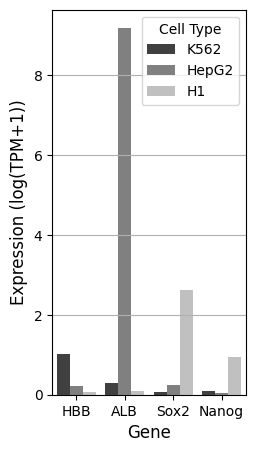

In [80]:
plot_results(results=results)